In [26]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ta.momentum import RSIIndicator
from ta.trend import MACD
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from alpha_vantage.timeseries import TimeSeries
import seaborn as sns

from dotenv import load_dotenv
import os

# Load environment variables from .env
load_dotenv()

# Get the API key
API_KEY = os.getenv("ALPHA_VANTAGE_API_KEY")


In [27]:
# Cell 2: Fetch Data from Alpha Vantage

symbol = "AAPL"
ts = TimeSeries(key=API_KEY, output_format='pandas')
data, _ = ts.get_daily(symbol=symbol, outputsize='full')
data = data.sort_index()
data = data.rename(columns={
    '1. open': 'open',
    '2. high': 'high',
    '3. low': 'low',
    '4. close': 'close',
    '5. volume': 'volume'
})



In [28]:
# Cell 3: Feature Engineering
data['return'] = data['close'].pct_change()
data['rsi'] = RSIIndicator(data['close'], window=14).rsi()
macd = MACD(data['close'])
data['macd'] = macd.macd()
data['macd_signal'] = macd.macd_signal()

# Forward return as signal (next day up/down)
data['target'] = np.where(data['return'].shift(-1) > 0, 1, 0)

# Drop NaNs
data = data.dropna()



In [29]:
 #Cell 4: Train-Test Split
features = ['rsi', 'macd', 'macd_signal']
X = data[features]
y = data['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)



In [30]:
# Cell 5: Model Training
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)




,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
# Cell 6: Evaluation
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))



              precision    recall  f1-score   support

           0       0.47      0.44      0.45       601
           1       0.53      0.55      0.54       680

    accuracy                           0.50      1281
   macro avg       0.50      0.50      0.50      1281
weighted avg       0.50      0.50      0.50      1281

ROC AUC Score: 0.5006361945776646


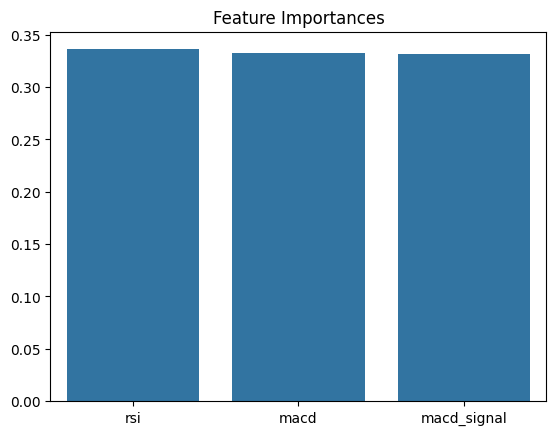

In [32]:
# Cell 7: Plot feature importance
importances = model.feature_importances_
sns.barplot(x=features, y=importances)
plt.title("Feature Importances")
plt.show()

In [33]:
# Crear DataFrame para backtesting
# Usamos 'data' como el DataFrame con los precios originales
# y X_test.index como las fechas de las predicciones

# Extraer precios de cierre
close_prices = data.loc[X_test.index, 'close']

# Crear DataFrame con señales y precios
signal_df = pd.DataFrame({
    'close': close_prices,
    'y_pred': y_pred
})
signal_df.index = pd.to_datetime(signal_df.index)
signal_df = signal_df[['close', 'y_pred']]  # Ordenar columnas

# Guardar CSV para usar en el siguiente notebook
output_path = "/workspaces/backtesting/investment-portfolio-project/data/signal_data.csv"
signal_df.to_csv(output_path)

print(f"✅ Archivo guardado en: {output_path}")
signal_df.head()


✅ Archivo guardado en: /workspaces/backtesting/investment-portfolio-project/data/signal_data.csv


,close,y_pred
date,,
2020-05-01,289.07,0
2020-05-04,293.16,0
2020-05-05,297.56,1
2020-05-06,300.63,0
2020-05-07,303.74,0
